=== Raised-Cosine Pulse ===
Symbol period T  : 1.0
Time window      : ±5 T  (10001 samples)
Roll-off factors : [0.0, 0.5, 0.75]



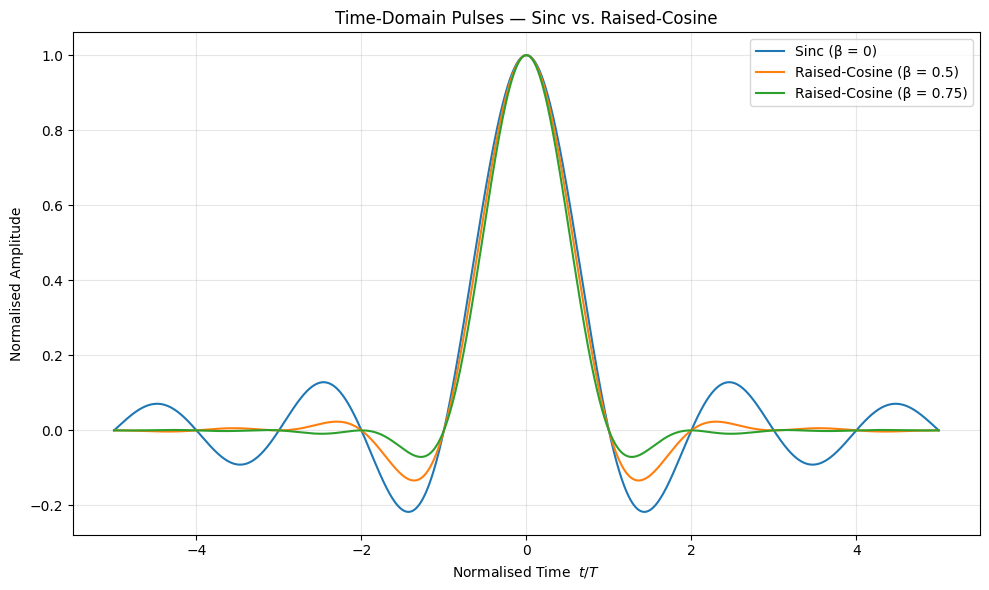

Audio preview: sinc


Audio preview: raised-cosine β=0.5


Audio preview: raised-cosine β=0.75


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

def Sinc(X: np.ndarray) -> np.ndarray:
    Y = np.empty_like(X, dtype=float)
    Zeros = np.isclose(X, 0.0)
    np.divide(np.sin(np.pi * X), np.pi * X, out=Y, where=~Zeros)
    Y[Zeros] = 1.0
    return Y

def IdealSincPulse(TimeVector: np.ndarray, SymbolPeriod: float = 1.0) -> np.ndarray:
    return Sinc(TimeVector / SymbolPeriod)

def RaisedCosinePulse(Beta: float, TimeVector: np.ndarray, SymbolPeriod: float = 1.0) -> np.ndarray:
    if Beta == 0.0:
        return IdealSincPulse(TimeVector, SymbolPeriod)

    SincPart = Sinc(TimeVector / SymbolPeriod)
    CosPart  = np.cos(np.pi * Beta * TimeVector / SymbolPeriod)
    Numerator   = SincPart * CosPart
    Denominator = 1.0 - (2.0 * Beta * TimeVector / SymbolPeriod) ** 2

    Pulse   = np.empty_like(TimeVector)
    Regular = ~np.isclose(Denominator, 0.0)
    Pulse[Regular] = Numerator[Regular] / Denominator[Regular]

    Singular = ~Regular
    if np.any(Singular):
        Pulse[Singular] = (np.pi / (4.0 * SymbolPeriod)) * Sinc(1.0 / (2.0 * Beta))
    return Pulse

def Normalise(Pulse: np.ndarray) -> np.ndarray:
    return Pulse / np.max(np.abs(Pulse))

SymbolPeriod   = 1.0             
TimeSpan       = 5                
NumSamples     = 10001
BetaList       = [0.0, 0.5, 0.75]

TimeVector = np.linspace(-TimeSpan * SymbolPeriod, TimeSpan * SymbolPeriod, NumSamples)
print("=== Raised-Cosine Pulse ===")
print(f"Symbol period T  : {SymbolPeriod}")
print(f"Time window      : ±{TimeSpan} T  ({NumSamples} samples)")
print(f"Roll-off factors : {BetaList}")
print("")

PulseDict = {}
for Beta in BetaList:
    Pulse = (IdealSincPulse(TimeVector, SymbolPeriod) if Beta == 0
             else RaisedCosinePulse(Beta, TimeVector, SymbolPeriod))
    PulseDict[Beta] = Normalise(Pulse)

plt.figure(figsize=(10, 6))
ColourCycle = {0.0: "C0", 0.5: "C1", 0.75: "C2"}
for Beta, Pulse in PulseDict.items():
    Label = "Sinc (β = 0)" if Beta == 0 \
            else rf"Raised-Cosine (β = {Beta})"
    plt.plot(TimeVector / SymbolPeriod, Pulse,
             label=Label, color=ColourCycle[Beta])
plt.title("Time-Domain Pulses — Sinc vs. Raised-Cosine")
plt.xlabel("Normalised Time  $t/T$")
plt.ylabel("Normalised Amplitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

SamplingRate  = 48_000
StretchFactor = 20

def PlayPulseAsAudio(Pulse: np.ndarray, Name: str) -> None:
    AudioClip = np.repeat(Pulse.astype(np.float32), StretchFactor)
    print(f"Audio preview: {Name}")
    display(Audio(AudioClip, rate=SamplingRate))

for Beta, Pulse in PulseDict.items():
    Name = "sinc" if Beta == 0 else f"raised-cosine β={Beta}"
    PlayPulseAsAudio(Pulse, Name)

# Report: Time-Domain Comparison of Sinc and Raised-Cosine Pulses

## 1. Introduction

In digital communications, the choice of pulse shape directly affects both spectral footprint (bandwidth) and inter-symbol interference (ISI).  
This report compares the ideal sinc pulse (infinite duration, perfectly bandlimited) with practical raised-cosine pulses (finite duration, adjustable roll-off).

---

## 2. Objectives

- **Generate** three pulse shapes:
  - Ideal sinc pulse  
  - Raised-cosine pulse with roll-off factor 0.5  
  - Raised-cosine pulse with roll-off factor 0.75  
- **Normalise** each pulse to unit peak amplitude.  
- **Plot** all pulses over a time range spanning five symbol periods on either side of zero.  
- **Preview** each pulse as a time-stretched audio clip.

---

## 3. Pulse Definitions

- **Sinc pulse**  
  The theoretical Nyquist pulse with zero ISI but infinite time-domain extent and slowly decaying side-lobes.

- **Raised-Cosine pulses**  
  Practical Nyquist pulses whose side-lobes are suppressed more quickly. The “roll-off factor” controls the trade-off between time-domain decay and spectral expansion.

---

## 4. Methodology

- **Sampling**  
  Create a uniformly spaced time vector covering ±5 symbol periods, with 10 001 sample points.
- **Implementation**  
  - `Sinc()` computes the sinc values.  
  - `IdealSincPulse()` and `RaisedCosinePulse()` generate the corresponding pulse shapes.  
  - `Normalise()` scales each pulse so its maximum absolute value is 1.
- **Visualization**  
  Plot the three normalised pulses on the same axes, with time expressed in units of the symbol period.
- **Audio Preview**  
  Repeat (stretch) each pulse in time and play back at 48 kHz to illustrate its ringing or smoothness.

---

## 5. Results

- **Main-lobe width**  
  - The sinc pulse has the narrowest main lobe in time (widest in frequency).  
  - Raised-cosine pulses broaden slightly as the roll-off factor increases.

- **Side-lobe suppression**  
  - Sinc exhibits pronounced, slowly decaying side lobes.  
  - Raised-cosine with higher roll-off shows much lower side-lobe levels.

- **Time-domain compactness**  
  Higher roll-off pulses decay faster in time, making them more compact for practical filter truncation.

---

## 6. Discussion

- **Bandwidth vs. time trade-off**  
  Increasing roll-off widens the signal’s occupied bandwidth but yields faster time-domain decay.
- **Zero ISI**  
  All pulses meet the Nyquist criterion (zero crossings at symbol-interval offsets), but raised-cosine shapes are easier to truncate without introducing ISI.
- **Aural impression**  
  The ideal sinc sounds “ringy” due to its strong side-lobes, whereas raised-cosine pulses sound smoother and less prone to ringing.

---

## 7. Conclusion

- **Ideal sinc** pulses are spectrally optimal but impractical because of their infinite duration and prominent ringing.
- **Raised-Cosine** pulses allow a tunable compromise: moderate roll-off values (e.g. 0.3–0.5) balance filter complexity, bandwidth compliance, and time-domain confinement.

---